# Eksploracja danych LINCS L1000 (CMap) i łączenie z BindingDB

Notebook krok po kroku:
1. Wczytanie metadanych (`compoundinfo`, `geneinfo`, `siginfo`)
2. Eksploracja każdego pliku – wymiary, kolumny, braki danych
3. Wczytanie macierzy ekspresji z pliku `.gctx` (podpróbka)
4. Próba łączenia z istniejącym datasetem **BindingDB** po `canonical_smiles` ↔ `Ligand SMILES` (inner join)
5. Jeśli za mało danych – fallback na łączenie po scaffoldach (Murcko scaffold)
6. Podsumowanie i eksport

## 0. Importy i ścieżki

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
from collections import Counter

# RDKit – do kanonizacji SMILES i scaffoldów
from rdkit import Chem
from rdkit.Chem.Scaffolds.MurckoScaffold import MakeScaffoldGeneric, GetScaffoldForMol

# cmapPy – oficjalne narzędzie do odczytu GCTX
from cmapPy.pandasGEXpress.parse import parse as parse_gctx

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ścieżki
HOME = Path.home()
COMPOUND_FILE = HOME / "compoundinfo_beta.txt"
GENE_FILE = HOME / "geneinfo_beta.txt"
SIG_FILE = HOME / "siginfo_beta.txt"
GCTX_FILE = HOME / "level5_beta_trt_cp_n720216x12328.gctx"

# Istniejący dataset BindingDB
CLEAN_PARQUET = Path("datasets/clean.parquet")

print("Pliki:")
for f in [COMPOUND_FILE, GENE_FILE, SIG_FILE, GCTX_FILE, CLEAN_PARQUET]:
    exists = "✓" if f.exists() else "✗"
    size_mb = f.stat().st_size / 1e6 if f.exists() else 0
    print(f"  {exists} {f.name:50s} {size_mb:>10.1f} MB")

Pliki:
  ✓ compoundinfo_beta.txt                                     4.6 MB
  ✓ geneinfo_beta.txt                                         1.1 MB
  ✓ siginfo_beta.txt                                        465.2 MB
  ✓ level5_beta_trt_cp_n720216x12328.gctx                 35518.4 MB
  ✓ clean.parquet                                            13.7 MB


---
## 1. Compound Info – metadane związków chemicznych

In [2]:
compounds = pl.read_csv(COMPOUND_FILE, separator="\t", ignore_errors=True)

print(f"Shape: {compounds.shape}")
print(f"Kolumny: {compounds.columns}")
print()
compounds.head(10)

Shape: (39321, 7)
Kolumny: ['pert_id', 'cmap_name', 'target', 'moa', 'canonical_smiles', 'inchi_key', 'compound_aliases']



pert_id,cmap_name,target,moa,canonical_smiles,inchi_key,compound_aliases
str,str,str,str,str,str,str
"""BRD-A08715367""","""L-theanine""","""""","""""","""CCNC(=O)CCC(N)C(O)=O""","""DATAGRPVKZEWHA-UHFFFAOYSA-N""","""l-theanine"""
"""BRD-A12237696""","""L-citrulline""","""""","""""","""NC(CCCNC(N)=O)C(O)=O""","""RHGKLRLOHDJJDR-UHFFFAOYSA-N""","""l-citrulline"""
"""BRD-A18795974""","""BRD-A18795974""","""""","""""","""CCCN(CCC)C1CCc2ccc(O)cc2C1""","""BLYMJBIZMIGWFK-UHFFFAOYSA-N""","""7-hydroxy-DPAT"""
"""BRD-A27924917""","""BRD-A27924917""","""""","""""","""NCC(O)(CS(O)(=O)=O)c1ccc(Cl)cc…","""WBSMZVIMANOCNX-UHFFFAOYSA-N""","""2-hydroxysaclofen"""
"""BRD-A35931254""","""BRD-A35931254""","""""","""""","""CN1CCc2cccc-3c2C1Cc1ccc(O)c(O)…","""VMWNQDUVQKEIOC-UHFFFAOYSA-N""","""r(-)-apomorphine"""
"""BRD-A39230911""","""chlorphensin""","""""","""""","""NC(=O)OCC(O)COc1ccc(Cl)cc1""","""SKPLBLUECSEIFO-UHFFFAOYSA-N""","""chlorphenesin-carbamate"""
"""BRD-A77577770""","""BRD-A77577770""","""""","""""","""CCCCCCCCCCCCCCCC(=O)OC(CC(O)=O…","""XOMRRQXKHMYMOC-UHFFFAOYSA-O""","""palmitoylcarnitine"""
"""BRD-A86415025""","""BRD-A86415025""","""""","""""","""C(C(N1CCCCC1)c1ccccc1)c1ccccc1""","""JQWJJJYHVHNXJH-UHFFFAOYSA-N""","""1-(1,2-diphenylethyl)piperidin…"
"""BRD-K05674516""","""PSI-7976""","""""","""""","""CC(C)OC(=O)[C@H](C)N[P@@](=O)(…","""TTZHDVOVKQGIBA-YBSJRAAASA-N""","""sofosbuvir"""


In [3]:
# Podstawowe statystyki
print("=== Compound Info – podsumowanie ===")
print(f"Liczba związków (wierszy):  {compounds.height}")
print(f"Unikalne pert_id:           {compounds['pert_id'].n_unique()}")
print(f"Unikalne cmap_name:         {compounds['cmap_name'].n_unique()}")
print()

# Braki danych
print("Braki danych (null / puste):")
for col in compounds.columns:
    null_count = compounds[col].null_count()
    # Policz też puste stringi
    if compounds[col].dtype == pl.Utf8:
        empty_count = compounds.filter(
            (pl.col(col) == "") | (pl.col(col) == '""')
        ).height
    else:
        empty_count = 0
    total_missing = null_count + empty_count
    pct = total_missing / compounds.height * 100
    print(f"  {col:25s}  null={null_count:>6d}  empty={empty_count:>6d}  total={total_missing:>6d}  ({pct:.1f}%)")

=== Compound Info – podsumowanie ===
Liczba związków (wierszy):  39321
Unikalne pert_id:           34419
Unikalne cmap_name:         33627

Braki danych (null / puste):
  pert_id                    null=     0  empty=     0  total=     0  (0.0%)
  cmap_name                  null=     0  empty=     0  total=     0  (0.0%)
  target                     null=     0  empty= 31275  total= 31275  (79.5%)
  moa                        null=     0  empty= 31275  total= 31275  (79.5%)
  canonical_smiles           null=     0  empty=  5790  total=  5790  (14.7%)
  inchi_key                  null=     0  empty= 12483  total= 12483  (31.7%)
  compound_aliases           null=     0  empty= 38466  total= 38466  (97.8%)


In [4]:
# Ile związków ma SMILES?
has_smiles = compounds.filter(
    pl.col("canonical_smiles").is_not_null() & 
    (pl.col("canonical_smiles") != "") &
    (pl.col("canonical_smiles") != '""')
)
print(f"Związki z canonical_smiles: {has_smiles.height} / {compounds.height} ({has_smiles.height/compounds.height*100:.1f}%)")
print(f"Unikalne SMILES w CMap:     {has_smiles['canonical_smiles'].n_unique()}")
print()

# Ile ma target / MOA?
has_target = compounds.filter(
    pl.col("target").is_not_null() & 
    (pl.col("target") != "") &
    (pl.col("target") != '""')
)
has_moa = compounds.filter(
    pl.col("moa").is_not_null() & 
    (pl.col("moa") != "") &
    (pl.col("moa") != '""')
)
print(f"Związki z target: {has_target.height} / {compounds.height} ({has_target.height/compounds.height*100:.1f}%)")
print(f"Związki z MOA:    {has_moa.height} / {compounds.height} ({has_moa.height/compounds.height*100:.1f}%)")

Związki z canonical_smiles: 33531 / 39321 (85.3%)
Unikalne SMILES w CMap:     28575

Związki z target: 8046 / 39321 (20.5%)
Związki z MOA:    8046 / 39321 (20.5%)


In [5]:
# Przykładowe targetty i MOA
print("Top 15 MOA:")
print(has_moa["moa"].value_counts().sort("count", descending=True).head(15))
print()
print("Top 15 targets:")
print(has_target["target"].value_counts().sort("count", descending=True).head(15))

Top 15 MOA:
shape: (15, 2)
┌────────────────────────────────┬───────┐
│ moa                            ┆ count │
│ ---                            ┆ ---   │
│ str                            ┆ u32   │
╞════════════════════════════════╪═══════╡
│ Serotonin receptor antagonist  ┆ 276   │
│ Dopamine receptor antagonist   ┆ 218   │
│ Dopamine receptor agonist      ┆ 216   │
│ VEGFR inhibitor                ┆ 199   │
│ Adrenergic receptor antagonist ┆ 195   │
│ …                              ┆ …     │
│ Calcium channel blocker        ┆ 109   │
│ Adrenergic receptor agonist    ┆ 107   │
│ Phosphodiesterase inhibitor    ┆ 102   │
│ HDAC inhibitor                 ┆ 99    │
│ CDK inhibitor                  ┆ 92    │
└────────────────────────────────┴───────┘

Top 15 targets:
shape: (15, 2)
┌────────┬───────┐
│ target ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ DRD2   ┆ 118   │
│ HTR2A  ┆ 112   │
│ NR3C1  ┆ 112   │
│ KDR    ┆ 105   │
│ PTGS2  ┆ 99    │
│ …      ┆ …     │
│

---
## 2. Gene Info – metadane genów (landmarki L1000)

In [6]:
genes = pl.read_csv(GENE_FILE, separator="\t", ignore_errors=True)

print(f"Shape: {genes.shape}")
print(f"Kolumny: {genes.columns}")
print()
genes.head(10)

Shape: (12328, 7)
Kolumny: ['gene_id', 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space']



gene_id,gene_symbol,ensembl_id,gene_title,gene_type,src,feature_space
i64,str,str,str,str,str,str
750,"""GAS8-AS1""","""ENSG00000221819""","""GAS8 antisense RNA 1""","""ncRNA""","""NCBI""","""inferred"""
6315,"""ATXN8OS""","""""","""ATXN8 opposite strand lncRNA""","""ncRNA""","""NCBI""","""inferred"""
7503,"""XIST""","""ENSG00000229807""","""X inactive specific transcript""","""ncRNA""","""NCBI""","""inferred"""
8552,"""INE1""","""ENSG00000224975""","""inactivation escape 1""","""ncRNA""","""NCBI""","""inferred"""
9834,"""FAM30A""","""ENSG00000226777""","""family with sequence similarit…","""ncRNA""","""NCBI""","""inferred"""
10141,"""LINC01587""","""ENSG00000082929""","""long intergenic non-protein co…","""ncRNA""","""NCBI""","""inferred"""
10255,"""HCG9""","""ENSG00000204625""","""HLA complex group 9""","""ncRNA""","""NCBI""","""inferred"""
10281,"""DSCR4""","""ENSG00000184029""","""Down syndrome critical region …","""ncRNA""","""NCBI""","""inferred"""
23434,"""LINC01565""","""ENSG00000198685""","""long intergenic non-protein co…","""ncRNA""","""NCBI""","""inferred"""


In [7]:
print("=== Gene Info – podsumowanie ===")
print(f"Unikalne gene_id:     {genes['gene_id'].n_unique()}")
print(f"Unikalne gene_symbol: {genes['gene_symbol'].n_unique()}")
print()

# Feature space breakdown – landmark vs inferred
print("Feature space:")
print(genes["feature_space"].value_counts().sort("count", descending=True))
print()

# Gene type breakdown
print("Gene type:")
print(genes["gene_type"].value_counts().sort("count", descending=True))
print()

# Landmark genes (978 oryginalnych)
landmarks = genes.filter(pl.col("feature_space") == "landmark")
print(f"Landmark genes: {landmarks.height}")
print(f"Inferred genes: {genes.filter(pl.col('feature_space') == 'inferred').height}")

=== Gene Info – podsumowanie ===
Unikalne gene_id:     12328
Unikalne gene_symbol: 12327

Feature space:
shape: (3, 2)
┌───────────────┬───────┐
│ feature_space ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ best inferred ┆ 9196  │
│ inferred      ┆ 2154  │
│ landmark      ┆ 978   │
└───────────────┴───────┘

Gene type:
shape: (4, 2)
┌────────────────┬───────┐
│ gene_type      ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ protein-coding ┆ 12146 │
│ pseudo         ┆ 98    │
│ ncRNA          ┆ 83    │
│ snoRNA         ┆ 1     │
└────────────────┴───────┘

Landmark genes: 978
Inferred genes: 2154


---
## 3. Sig Info – metadane sygnatur (eksperymentów)

In [8]:
# siginfo jest duży (~465 MB), wczytujemy lazy
siginfo = pl.read_csv(SIG_FILE, separator="\t", ignore_errors=True, infer_schema_length=10000)

print(f"Shape: {siginfo.shape}")
print(f"Kolumny: {siginfo.columns}")
print()
siginfo.head(5)

Shape: (1201944, 37)
Kolumny: ['bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_itime', 'pert_time', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'nsample', 'cc_q75', 'ss_ngene', 'tas', 'pct_self_rank_q25', 'wt', 'median_recall_rank_spearman', 'median_recall_rank_wtcs_50', 'median_recall_score_spearman', 'median_recall_score_wtcs_50', 'batch_effect_tstat', 'batch_effect_tstat_pct', 'is_hiq', 'qc_pass', 'pert_id', 'sig_id', 'pert_type', 'cell_iname', 'det_wells', 'det_plates', 'distil_ids', 'build_name', 'project_code', 'cmap_name', 'is_exemplar_sig', 'is_ncs_sig', 'is_null_sig']



bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_itime,pert_time,pert_time_unit,cell_mfc_name,pert_mfc_id,nsample,cc_q75,ss_ngene,tas,pct_self_rank_q25,wt,median_recall_rank_spearman,median_recall_rank_wtcs_50,median_recall_score_spearman,median_recall_score_wtcs_50,batch_effect_tstat,batch_effect_tstat_pct,is_hiq,qc_pass,pert_id,sig_id,pert_type,cell_iname,det_wells,det_plates,distil_ids,build_name,project_code,cmap_name,is_exemplar_sig,is_ncs_sig,is_null_sig
str,f64,f64,str,str,str,f64,str,str,str,i64,f64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,i64
"""b17""",null,100.0,"""ug/ml""","""100 ug/ml""","""336 h""",336.0,"""h""","""N8""","""BRD-U44432129""",4,0.6164,446,0.530187,0.0,"""0.26,0.26,0.22,0.26""",0.925926,1.15741,0.548655,0.705263,-2.31,0.488085,1,1,"""BRD-U44432129""","""MET001_N8_XH:BRD-U44432129:100…","""trt_cp""","""NAMEC8""","""H05|H06|H07|H08""","""MET001_N8_XH_X1_B17""","""MET001_N8_XH_X1_B17:H05|MET001…",null,"""MET""","""BRD-U44432129""",0,0,0
"""b15""",10.0,10.0,"""uM""","""10 uM""","""3 h""",3.0,"""h""","""A549""","""BRD-K81418486""",3,0.49,263,0.363,0.544959,"""0.34,0.34,0.31""",1.90736,0.544959,0.426195,0.777817,17.02,71.7485,1,1,"""BRD-K81418486""","""ABY001_A549_XH:BRD-K81418486:1…","""trt_cp""","""A549""","""L04|L08|L12""","""ABY001_A549_XH_X1_B15""","""ABY001_A549_XH_X1_B15:L04|ABY0…",null,"""ABY""","""vorinostat""",0,1,0
"""b15""",2.5,2.5,"""uM""","""2.5 uM""","""24 h""",24.0,"""h""","""HT29""","""BRD-K70511574""",2,0.4,138,0.237575,0.0,"""0.50,0.50""",0.285714,0.285714,0.396519,0.685816,23.55,85.4436,1,1,"""BRD-K70511574""","""ABY001_HT29_XH:BRD-K70511574:2…","""trt_cp""","""HT29""","""E18|E22""","""ABY001_HT29_XH_X1_B15""","""ABY001_HT29_XH_X1_B15:E18|ABY0…",null,"""ABY""","""HMN-214""",0,1,0
"""b18""",10.0,10.0,"""uM""","""10 uM""","""3 h""",3.0,"""h""","""HME1""","""BRD-K81418486""",1,0.0,0,0.0,0.0,"""1.00""",0.0,0.0,0.0,0.0,8.13,32.2997,0,1,"""BRD-K81418486""","""LTC002_HME1_3H:BRD-K81418486:1…","""trt_cp""","""HME1""","""F19""","""LTC002_HME1_3H_X1_B18""","""LTC002_HME1_3H_X1_B18:F19""",null,"""LTC""","""vorinostat""",0,0,0
"""b15""",10.0,10.0,"""uM""","""10 uM""","""3 h""",3.0,"""h""","""H1975""","""BRD-A61304759""",3,0.3678,263,0.314495,2.62431,"""0.37,0.40,0.23""",13.8122,25.2762,0.217361,0.50742,32.1,93.6262,0,1,"""BRD-A61304759""","""ABY001_H1975_XH:BRD-A61304759:…","""trt_cp""","""H1975""","""P01|P05|P09""","""ABY001_H1975_XH_X1_B15""","""ABY001_H1975_XH_X1_B15:P01|ABY…",null,"""ABY""","""tanespimycin""",0,0,0


In [9]:
print("=== Sig Info – podsumowanie ===")
print(f"Liczba sygnatur (wierszy):    {siginfo.height}")
print(f"Unikalne sig_id:              {siginfo['sig_id'].n_unique()}")
print(f"Unikalne pert_id:             {siginfo['pert_id'].n_unique()}")
print(f"Unikalne cell_iname (linie):  {siginfo['cell_iname'].n_unique()}")
print(f"Unikalne cmap_name:           {siginfo['cmap_name'].n_unique()}")
print()

# Rozkład pert_type
print("pert_type:")
print(siginfo["pert_type"].value_counts().sort("count", descending=True))
print()

# Top linie komórkowe
print("Top 10 linii komórkowych:")
print(siginfo["cell_iname"].value_counts().sort("count", descending=True).head(10))

=== Sig Info – podsumowanie ===
Liczba sygnatur (wierszy):    1201944
Unikalne sig_id:              1201944
Unikalne pert_id:             83588
Unikalne cell_iname (linie):  248
Unikalne cmap_name:           46934

pert_type:
shape: (16, 2)
┌─────────────────┬────────┐
│ pert_type       ┆ count  │
│ ---             ┆ ---    │
│ str             ┆ u32    │
╞═════════════════╪════════╡
│ trt_cp          ┆ 720216 │
│ trt_sh          ┆ 177263 │
│ trt_xpr         ┆ 140945 │
│ ctl_vehicle     ┆ 39448  │
│ trt_sh.cgs      ┆ 36720  │
│ …               ┆ …      │
│ trt_si          ┆ 162    │
│ ctl_vector.cns  ┆ 137    │
│ ctl_vehicle.cns ┆ 61     │
│ ctl_untrt.cns   ┆ 30     │
│ ctl_x           ┆ 1      │
└─────────────────┴────────┘

Top 10 linii komórkowych:
shape: (10, 2)
┌────────────┬────────┐
│ cell_iname ┆ count  │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ MCF7       ┆ 110887 │
│ PC3        ┆ 107579 │
│ A549       ┆ 101214 │
│ A375       ┆ 90241  │
│ HT29  

In [10]:
# Rozkład dawek i czasów
print("Rozkład pert_time (godziny):")
if "pert_time" in siginfo.columns:
    time_col = siginfo["pert_time"].cast(pl.Utf8)
    print(time_col.value_counts().sort("count", descending=True).head(10))
print()

print("Rozkład nearest_dose:")
if "nearest_dose" in siginfo.columns:
    dose_col = siginfo["nearest_dose"].cast(pl.Utf8)
    print(dose_col.value_counts().sort("count", descending=True).head(10))
print()

# Quality metrics
print("Jakość sygnatur:")
if "is_hiq" in siginfo.columns:
    print(f"  is_hiq:  {siginfo['is_hiq'].value_counts().sort('count', descending=True)}")
if "qc_pass" in siginfo.columns:
    print(f"  qc_pass: {siginfo['qc_pass'].value_counts().sort('count', descending=True)}")

Rozkład pert_time (godziny):
shape: (10, 2)
┌───────────┬────────┐
│ pert_time ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ 24.0      ┆ 592155 │
│ 96.0      ┆ 374798 │
│ 6.0       ┆ 145491 │
│ 120.0     ┆ 33200  │
│ 144.0     ┆ 18891  │
│ 3.0       ┆ 13188  │
│ 4.0       ┆ 8037   │
│ 48.0      ┆ 6916   │
│ 72.0      ┆ 3496   │
│ 2.0       ┆ 2975   │
└───────────┴────────┘

Rozkład nearest_dose:
shape: (10, 2)
┌──────────────┬────────┐
│ nearest_dose ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ null         ┆ 483874 │
│ 10.0         ┆ 220474 │
│ 1.11         ┆ 68487  │
│ 4.0          ┆ 63285  │
│ 3.33         ┆ 56863  │
│ 0.37         ┆ 40474  │
│ 0.04         ┆ 37691  │
│ 0.125        ┆ 29083  │
│ 20.0         ┆ 22999  │
│ 0.08         ┆ 22579  │
└──────────────┴────────┘

Jakość sygnatur:
  is_hiq:  shape: (2, 2)
┌────────┬────────┐
│ is_hiq ┆ count  │
│ ---    ┆ ---    │
│ i64    ┆ u32    │
╞════════╪═

---
## 4. Plik GCTX – macierz ekspresji genów

Plik `.gctx` to format HDF5 zawierający macierz `[geny × sygnatury]`.  
Plik jest **ogromny** (~35 GB), więc na początek sprawdzimy jego strukturę i wczytamy małą podpróbkę.

In [11]:
# Podgląd struktury HDF5
print("=== Struktura pliku GCTX (HDF5) ===")
with h5py.File(GCTX_FILE, "r") as f:
    def print_hdf5_structure(name, obj):
        indent = "  " * name.count("/")
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}📊 {name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{indent}📁 {name}")
    f.visititems(print_hdf5_structure)

=== Struktura pliku GCTX (HDF5) ===
📁 0
  📁 0/DATA
    📁 0/DATA/0
      📊 0/DATA/0/matrix: shape=(720216, 12328), dtype=float32
  📁 0/META
    📁 0/META/COL
      📊 0/META/COL/id: shape=(720216,), dtype=|S55
    📁 0/META/ROW
      📊 0/META/ROW/id: shape=(12328,), dtype=|S12


In [12]:
# Wymiary macierzy
with h5py.File(GCTX_FILE, "r") as f:
    matrix = f["0/DATA/0/matrix"]
    print(f"Wymiary macierzy: {matrix.shape}")
    print(f"  → Wiersze (sygnatury): {matrix.shape[0]:,}")
    print(f"  → Kolumny (geny):      {matrix.shape[1]:,}")
    print(f"  → dtype: {matrix.dtype}")
    print(f"  → Rozmiar w pamięci: {matrix.shape[0] * matrix.shape[1] * 4 / 1e9:.1f} GB (float32)")
    
    # IDs
    col_ids = f["0/META/COL/id"][:]
    row_ids = f["0/META/ROW/id"][:]
    print(f"\nRow IDs (sig_ids) – pierwsze 5: {row_ids[:5]}")
    print(f"Col IDs (gene_ids) – pierwsze 5: {col_ids[:5]}")

Wymiary macierzy: (720216, 12328)
  → Wiersze (sygnatury): 720,216
  → Kolumny (geny):      12,328
  → dtype: float32
  → Rozmiar w pamięci: 35.5 GB (float32)

Row IDs (sig_ids) – pierwsze 5: [b'10' b'100' b'1000' b'10000' b'10001']
Col IDs (gene_ids) – pierwsze 5: [b'ABY001_A375_XH:BRD-A61304759:0.625:24'
 b'ABY001_A375_XH:BRD-A61304759:0.625:3'
 b'ABY001_A375_XH:BRD-A61304759:10:24'
 b'ABY001_A375_XH:BRD-A61304759:10:3'
 b'ABY001_A375_XH:BRD-A61304759:2.5:24']


In [13]:
# Wczytanie małej podpróbki z cmapPy (100 sygnatur × wszystkie geny)
# To pokaże jak wygląda macierz z-score'ów
print("Wczytywanie podpróbki 100 sygnatur...")

with h5py.File(GCTX_FILE, "r") as f:
    sample_sids = [x.decode() if isinstance(x, bytes) else str(x) for x in f["0/META/ROW/id"][:100]]

gctx_sample = parse_gctx(str(GCTX_FILE), rid=sample_sids)
print(f"Podpróbka shape: {gctx_sample.data_df.shape}")
print(f"\nPierwsze 5 wierszy × 10 kolumn:")
gctx_sample.data_df.iloc[:5, :10]

Wczytywanie podpróbki 100 sygnatur...
Podpróbka shape: (100, 720216)

Pierwsze 5 wierszy × 10 kolumn:


cid,ABY001_A375_XH:BRD-A61304759:0.625:24,ABY001_A375_XH:BRD-A61304759:0.625:3,ABY001_A375_XH:BRD-A61304759:10:24,ABY001_A375_XH:BRD-A61304759:10:3,ABY001_A375_XH:BRD-A61304759:2.5:24,ABY001_A375_XH:BRD-A61304759:2.5:3,ABY001_A375_XH:BRD-A90490067:0.625:24,ABY001_A375_XH:BRD-A90490067:0.625:3,ABY001_A375_XH:BRD-A90490067:10:24,ABY001_A375_XH:BRD-A90490067:10:3
rid,,,,,,,,,,
10,-0.02435,0.296080,-0.341348,0.826170,0.578998,-0.226271,-0.017583,-0.467870,0.478888,0.893431
100,0.70715,-0.855923,1.393475,-0.658590,1.990247,-0.816748,-0.126917,0.552741,-0.346516,-0.165648
1000,-1.53065,-0.976824,-0.938388,-1.117790,-0.241152,-0.236283,1.859383,0.448146,1.100482,0.733290
10000,-0.69105,-2.368536,0.033532,-1.195679,-0.269050,-0.257835,0.009758,-0.242909,0.189627,0.322729
10001,0.79380,0.836673,0.776472,-0.274785,0.458225,0.445442,-0.515106,-0.252442,-1.147002,1.434985


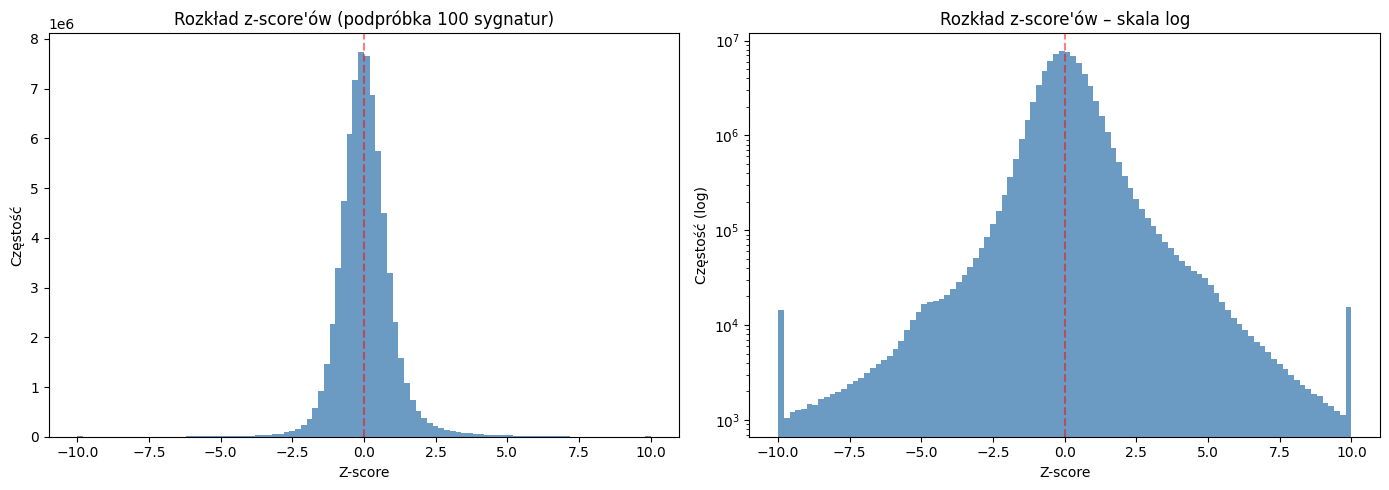


Statystyki z-score:
  Mean:   0.0476
  Std:    1.0050
  Min:    -10.0000
  Max:    10.0000
  NaN:    0


In [14]:
# Rozkład wartości z-score w podpróbce
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vals = gctx_sample.data_df.values.flatten()
vals = vals[~np.isnan(vals)]

axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Z-score")
axes[0].set_ylabel("Częstość")
axes[0].set_title("Rozkład z-score'ów (podpróbka 100 sygnatur)")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

axes[1].hist(vals, bins=100, color="steelblue", edgecolor="none", alpha=0.8, log=True)
axes[1].set_xlabel("Z-score")
axes[1].set_ylabel("Częstość (log)")
axes[1].set_title("Rozkład z-score'ów – skala log")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nStatystyki z-score:")
print(f"  Mean:   {vals.mean():.4f}")
print(f"  Std:    {vals.std():.4f}")
print(f"  Min:    {vals.min():.4f}")
print(f"  Max:    {vals.max():.4f}")
print(f"  NaN:    {np.isnan(gctx_sample.data_df.values).sum()}")

---
## 5. Łączenie z istniejącym datasetem BindingDB

Strategia:
1. **Inner join po canonical SMILES** – bezpośrednie dopasowanie
2. Jeśli za mało wyników → **join po Murcko scaffold** (fallback)

In [15]:
# Wczytanie BindingDB clean dataset
bindingdb = pl.read_parquet(CLEAN_PARQUET)
print(f"BindingDB clean shape:       {bindingdb.shape}")
print(f"Kolumny:                     {bindingdb.columns}")
print(f"Unikalne Ligand SMILES:      {bindingdb['Ligand SMILES'].n_unique()}")
print(f"Unikalne proteiny:           {bindingdb['Full_Protein_Sequence'].n_unique()}")
print()
bindingdb.head(3)

BindingDB clean shape:       (451858, 5)
Kolumny:                     ['Ligand SMILES', 'Full_Protein_Sequence', 'Ki (nM)', 'pKi', 'is_active']
Unikalne Ligand SMILES:      236379
Unikalne proteiny:           3580



Ligand SMILES,Full_Protein_Sequence,Ki (nM),pKi,is_active
str,str,f64,f64,bool
"""OCC1(CCCC1)N1CCN(CC1)C1CCc2ccc…","""MPVRRGHVAPQNTFLDTIIRKFEGQSRKFI…",709.0,6.149354,false
"""CCN(CC)CC(N1CCN(C)CC1)c1ccc(F)…","""MVNSTHRGMHTSLHLWNRSSYRLHSNASES…",100.0,7.0,true
"""CC12CC3CC(C)(C1)CC(C3)(C2)NC(=…","""MEECWVTEIANGSKDGLDSNPMKDYMILSG…",160.0,6.79588,false


### 5.1 Kanonizacja SMILES

Aby porównywać SMILES z obu źródeł, musimy je skanonizować (RDKit canonical).

In [16]:
def canonicalize_smiles(smi: str) -> str | None:
    """Kanonizuj SMILES z RDKit. Zwraca None dla nieprawidłowych."""
    if smi is None or smi == "" or smi == '""':
        return None
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

# Kanonizacja SMILES w CMap compounds
print("Kanonizacja SMILES w CMap compoundinfo...")
cmap_smiles = has_smiles.with_columns(
    pl.col("canonical_smiles")
      .map_elements(canonicalize_smiles, return_dtype=pl.Utf8)
      .alias("canonical_smiles_rdkit")
).filter(pl.col("canonical_smiles_rdkit").is_not_null())

print(f"CMap compounds z poprawnymi SMILES: {cmap_smiles.height}")
print(f"Unikalne kanoniczne SMILES (CMap):  {cmap_smiles['canonical_smiles_rdkit'].n_unique()}")

Kanonizacja SMILES w CMap compoundinfo...


[15:12:00] SMILES Parse Error: syntax error while parsing: restricted
[15:12:00] SMILES Parse Error: syntax error while parsing: restricted
[15:12:00] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:00] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:00] SMILES Parse Error: syntax error while parsing: restricted
[15:12:00] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:01] SMILES Parse Error: syntax error while parsing: restricted
[15:12:01] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:01] SMILES Parse Error: syntax error while parsing: restricted
[15:12:01] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:01] SMILES Parse Error: syntax error while parsing: restricted
[15:12:01] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'
[15:12:01] SMILES Parse Error: syntax er

CMap compounds z poprawnymi SMILES: 33515
Unikalne kanoniczne SMILES (CMap):  28477


In [17]:
# Kanonizacja SMILES w BindingDB
print("Kanonizacja SMILES w BindingDB...")
bindingdb_canon = bindingdb.with_columns(
    pl.col("Ligand SMILES")
      .map_elements(canonicalize_smiles, return_dtype=pl.Utf8)
      .alias("canonical_smiles_rdkit")
).filter(pl.col("canonical_smiles_rdkit").is_not_null())

print(f"BindingDB z poprawnymi SMILES:       {bindingdb_canon.height}")
print(f"Unikalne kanoniczne SMILES (BDB):    {bindingdb_canon['canonical_smiles_rdkit'].n_unique()}")

Kanonizacja SMILES w BindingDB...
BindingDB z poprawnymi SMILES:       451858
Unikalne kanoniczne SMILES (BDB):    235835


### 5.2 Inner join po kanonicznych SMILES

In [18]:
# Zbiór unikalnych SMILES z obu stron
cmap_unique = set(cmap_smiles["canonical_smiles_rdkit"].unique().to_list())
bdb_unique = set(bindingdb_canon["canonical_smiles_rdkit"].unique().to_list())

overlap = cmap_unique & bdb_unique

print(f"Unikalne SMILES w CMap:       {len(cmap_unique):>8,}")
print(f"Unikalne SMILES w BindingDB:  {len(bdb_unique):>8,}")
print(f"Wspólne SMILES (overlap):     {len(overlap):>8,}")
print(f"  → % CMap w BindingDB:       {len(overlap)/len(cmap_unique)*100:.2f}%")
print(f"  → % BindingDB w CMap:        {len(overlap)/len(bdb_unique)*100:.2f}%")

Unikalne SMILES w CMap:         28,477
Unikalne SMILES w BindingDB:   235,835
Wspólne SMILES (overlap):        1,686
  → % CMap w BindingDB:       5.92%
  → % BindingDB w CMap:        0.71%


In [19]:
# Inner join – wiersze z BindingDB które mają odpowiadający compound w CMap
merged_direct = bindingdb_canon.join(
    cmap_smiles.select(["pert_id", "cmap_name", "target", "moa", "inchi_key", "canonical_smiles_rdkit"]).unique(),
    on="canonical_smiles_rdkit",
    how="inner"
)

print(f"\n=== Wynik inner join (direct SMILES match) ===")
print(f"Wierszy po join:              {merged_direct.height:,}")
print(f"Unikalne ligandy:             {merged_direct['canonical_smiles_rdkit'].n_unique():,}")
print(f"Unikalne proteiny:            {merged_direct['Full_Protein_Sequence'].n_unique():,}")
print(f"Unikalne pert_id (CMap):      {merged_direct['pert_id'].n_unique():,}")
print()
merged_direct.head(5)


=== Wynik inner join (direct SMILES match) ===
Wierszy po join:              45,967
Unikalne ligandy:             1,686
Unikalne proteiny:            1,476
Unikalne pert_id (CMap):      1,703



Ligand SMILES,Full_Protein_Sequence,Ki (nM),pKi,is_active,canonical_smiles_rdkit,pert_id,cmap_name,target,moa,inchi_key
str,str,f64,f64,bool,str,str,str,str,str,str
"""CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC…","""MIRAFAQPSTPPYQPLSSCLSEDTERKFKG…",5000.0,5.30103,false,"""Cc1nc2n(c(=O)c1CCN1CCC(c3noc4c…","""BRD-K53857191""","""risperidone""","""HTR1A""","""Dopamine receptor antagonist""","""RAPZEAPATHNIPO-UHFFFAOYSA-N"""
"""CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC…","""MIRAFAQPSTPPYQPLSSCLSEDTERKFKG…",5000.0,5.30103,false,"""Cc1nc2n(c(=O)c1CCN1CCC(c3noc4c…","""BRD-K53857191""","""risperidone""","""HTR2A""","""Dopamine receptor antagonist""","""RAPZEAPATHNIPO-UHFFFAOYSA-N"""
"""CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC…","""MIRAFAQPSTPPYQPLSSCLSEDTERKFKG…",5000.0,5.30103,false,"""Cc1nc2n(c(=O)c1CCN1CCC(c3noc4c…","""BRD-K53857191""","""risperidone""","""HTR1A""","""Serotonin receptor antagonist""","""RAPZEAPATHNIPO-UHFFFAOYSA-N"""
"""CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC…","""MIRAFAQPSTPPYQPLSSCLSEDTERKFKG…",5000.0,5.30103,false,"""Cc1nc2n(c(=O)c1CCN1CCC(c3noc4c…","""BRD-K53857191""","""risperidone""","""DRD2""","""Serotonin receptor antagonist""","""RAPZEAPATHNIPO-UHFFFAOYSA-N"""
"""CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC…","""MIRAFAQPSTPPYQPLSSCLSEDTERKFKG…",5000.0,5.30103,false,"""Cc1nc2n(c(=O)c1CCN1CCC(c3noc4c…","""BRD-K53857191""","""risperidone""","""DRD4""","""Serotonin receptor antagonist""","""RAPZEAPATHNIPO-UHFFFAOYSA-N"""


In [20]:
# Podsumowanie bezpośredniego łączenia
DIRECT_THRESHOLD = 1000  # minimalna liczba unikalnych ligandów

n_direct_ligands = merged_direct['canonical_smiles_rdkit'].n_unique()
print(f"Unikalnych ligandów po direct join: {n_direct_ligands}")
print(f"Próg wystarczalności:               {DIRECT_THRESHOLD}")

if n_direct_ligands >= DIRECT_THRESHOLD:
    print(f"\n✅ Direct join daje wystarczającą liczbę danych!")
    USE_SCAFFOLD = False
else:
    print(f"\n⚠️ Direct join daje za mało danych. Przechodzimy do scaffold matching.")
    USE_SCAFFOLD = True

print(f"\nUżywamy scaffold fallback: {USE_SCAFFOLD}")

Unikalnych ligandów po direct join: 1686
Próg wystarczalności:               1000

✅ Direct join daje wystarczającą liczbę danych!

Używamy scaffold fallback: False


### 5.3 Scaffold-based matching (fallback)

Jeśli bezpośrednie łączenie po SMILES dało za mało danych, łączymy po **generic Murcko scaffold** – rdzeniu strukturalnym cząsteczki.

In [21]:
def get_generic_scaffold(smi: str) -> str | None:
    """Wyznacz generic Murcko scaffold dla SMILES."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        scaffold = GetScaffoldForMol(mol)
        generic = MakeScaffoldGeneric(scaffold)
        return Chem.MolToSmiles(generic)
    except:
        return None

if USE_SCAFFOLD:
    print("Obliczanie scaffoldów dla CMap...")
    cmap_with_scaffold = cmap_smiles.with_columns(
        pl.col("canonical_smiles_rdkit")
          .map_elements(get_generic_scaffold, return_dtype=pl.Utf8)
          .alias("scaffold")
    ).filter(pl.col("scaffold").is_not_null())
    print(f"  CMap z scaffoldem: {cmap_with_scaffold.height}, unikalne scaffoldy: {cmap_with_scaffold['scaffold'].n_unique()}")

    print("Obliczanie scaffoldów dla BindingDB...")
    bdb_with_scaffold = bindingdb_canon.with_columns(
        pl.col("canonical_smiles_rdkit")
          .map_elements(get_generic_scaffold, return_dtype=pl.Utf8)
          .alias("scaffold")
    ).filter(pl.col("scaffold").is_not_null())
    print(f"  BindingDB z scaffoldem: {bdb_with_scaffold.height}, unikalne scaffoldy: {bdb_with_scaffold['scaffold'].n_unique()}")
    
    # Overlap scaffoldów
    cmap_scaffolds = set(cmap_with_scaffold["scaffold"].unique().to_list())
    bdb_scaffolds = set(bdb_with_scaffold["scaffold"].unique().to_list())
    scaffold_overlap = cmap_scaffolds & bdb_scaffolds
    
    print(f"\nUnikalne scaffoldy CMap:       {len(cmap_scaffolds):>8,}")
    print(f"Unikalne scaffoldy BindingDB:  {len(bdb_scaffolds):>8,}")
    print(f"Wspólne scaffoldy:             {len(scaffold_overlap):>8,}")
    print(f"  → % CMap scaffold w BDB:     {len(scaffold_overlap)/len(cmap_scaffolds)*100:.2f}%")
    print(f"  → % BDB scaffold w CMap:     {len(scaffold_overlap)/len(bdb_scaffolds)*100:.2f}%")
else:
    print("Scaffold matching nie jest potrzebny – direct join wystarczy.")

Scaffold matching nie jest potrzebny – direct join wystarczy.


In [22]:
if USE_SCAFFOLD:
    # Inner join po scaffold
    merged_scaffold = bdb_with_scaffold.join(
        cmap_with_scaffold.select(["pert_id", "cmap_name", "target", "moa", "canonical_smiles_rdkit", "scaffold"]).unique(),
        on="scaffold",
        how="inner",
        suffix="_cmap"
    )
    
    print(f"\n=== Wynik inner join (scaffold match) ===")
    print(f"Wierszy po join:              {merged_scaffold.height:,}")
    print(f"Unikalne ligandy (BDB):       {merged_scaffold['canonical_smiles_rdkit'].n_unique():,}")
    print(f"Unikalne ligandy (CMap):      {merged_scaffold['canonical_smiles_rdkit_cmap'].n_unique():,}")
    print(f"Unikalne proteiny:            {merged_scaffold['Full_Protein_Sequence'].n_unique():,}")
    print(f"Unikalne scaffoldy:           {merged_scaffold['scaffold'].n_unique():,}")
    print()
    merged_scaffold.head(5)
else:
    print("Pomijamy – direct join wystarczył.")

Pomijamy – direct join wystarczył.


---
## 6. Podsumowanie i wizualizacja

In [23]:
# Wybór finalnego datasetu
if USE_SCAFFOLD:
    final_merged = merged_scaffold
    join_type = "scaffold"
else:
    final_merged = merged_direct
    join_type = "direct SMILES"

print(f"=== PODSUMOWANIE ===")
print(f"Typ łączenia:                 {join_type}")
print(f"Wierszy w merged dataset:     {final_merged.height:,}")
print(f"Kolumny:                      {final_merged.columns}")
print()

# Porównanie z oryginalnym BindingDB
print("Porównanie z oryginalnym BindingDB:")
print(f"  BindingDB oryg. wierszy:    {bindingdb.height:,}")
print(f"  Po merge wierszy:           {final_merged.height:,}")
print(f"  Procent zachowany:          {final_merged.height/bindingdb.height*100:.2f}%")
print()

# Rozkład is_active
if "is_active" in final_merged.columns:
    print("Rozkład is_active:")
    print(final_merged["is_active"].value_counts().sort("is_active"))

=== PODSUMOWANIE ===
Typ łączenia:                 direct SMILES
Wierszy w merged dataset:     45,967
Kolumny:                      ['Ligand SMILES', 'Full_Protein_Sequence', 'Ki (nM)', 'pKi', 'is_active', 'canonical_smiles_rdkit', 'pert_id', 'cmap_name', 'target', 'moa', 'inchi_key']

Porównanie z oryginalnym BindingDB:
  BindingDB oryg. wierszy:    451,858
  Po merge wierszy:           45,967
  Procent zachowany:          10.17%

Rozkład is_active:
shape: (2, 2)
┌───────────┬───────┐
│ is_active ┆ count │
│ ---       ┆ ---   │
│ bool      ┆ u32   │
╞═══════════╪═══════╡
│ false     ┆ 29898 │
│ true      ┆ 16069 │
└───────────┴───────┘


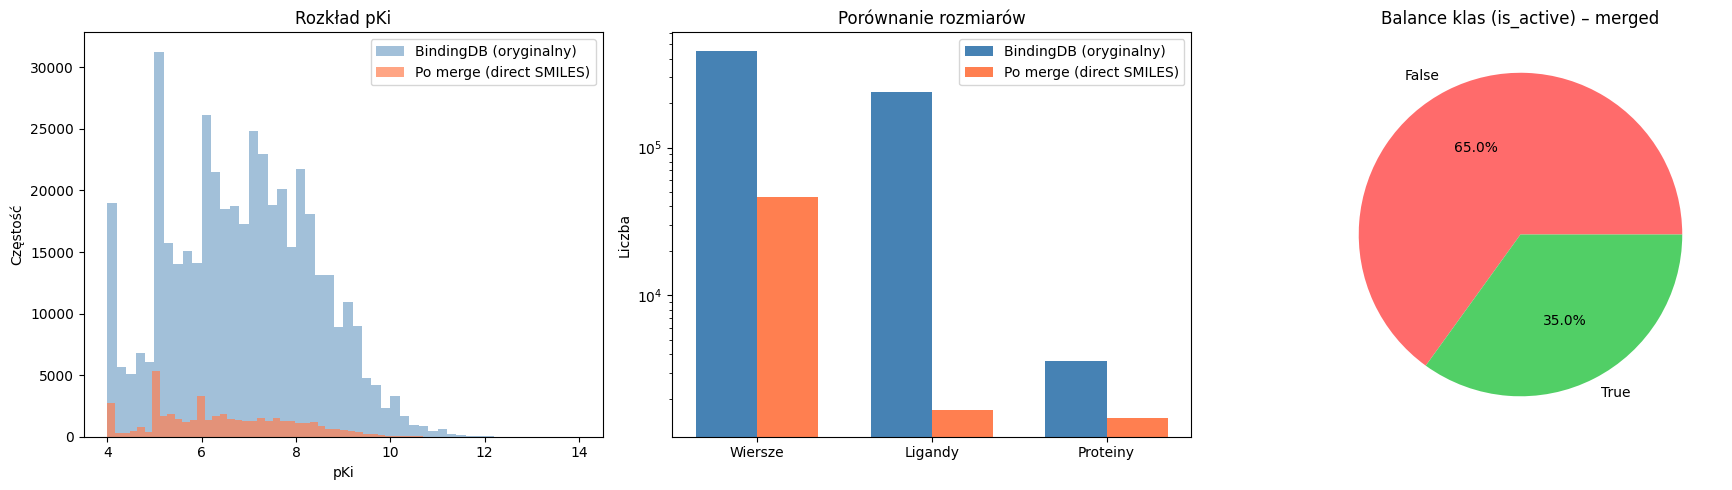

In [24]:
# Wizualizacja – Venn diagram (koncepcyjny)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Rozkład pKi w merged vs original
if "pKi" in final_merged.columns:
    axes[0].hist(bindingdb["pKi"].to_list(), bins=50, alpha=0.5, label="BindingDB (oryginalny)", color="steelblue")
    axes[0].hist(final_merged["pKi"].to_list(), bins=50, alpha=0.7, label=f"Po merge ({join_type})", color="coral")
    axes[0].set_xlabel("pKi")
    axes[0].set_ylabel("Częstość")
    axes[0].set_title("Rozkład pKi")
    axes[0].legend()

# 2. Liczebności
categories = ["Wiersze", "Ligandy", "Proteiny"]
bdb_counts = [
    bindingdb.height,
    bindingdb["Ligand SMILES"].n_unique(),
    bindingdb["Full_Protein_Sequence"].n_unique()
]
merged_counts = [
    final_merged.height,
    final_merged["canonical_smiles_rdkit"].n_unique() if "canonical_smiles_rdkit" in final_merged.columns else 0,
    final_merged["Full_Protein_Sequence"].n_unique()
]

x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, bdb_counts, w, label="BindingDB (oryginalny)", color="steelblue")
axes[1].bar(x + w/2, merged_counts, w, label=f"Po merge ({join_type})", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Liczba")
axes[1].set_title("Porównanie rozmiarów")
axes[1].legend()
axes[1].set_yscale("log")

# 3. Balance klas
if "is_active" in final_merged.columns:
    vc = final_merged["is_active"].value_counts().sort("is_active")
    labels_list = [str(v) for v in vc["is_active"].to_list()]
    counts = vc["count"].to_list()
    axes[2].pie(counts, labels=labels_list, autopct="%1.1f%%", colors=["#ff6b6b", "#51cf66"])
    axes[2].set_title("Balance klas (is_active) – merged")

plt.tight_layout()
plt.show()

---
## 7. Mapowanie sig_id na pert_id – przygotowanie do ekstrakcji profili L1000

Dla związków ze wspólnej części (merged), sprawdzamy ile mają sygnatur w pliku GCTX.

In [25]:
# Znajdź pert_ids które nas interesują
if "pert_id" in final_merged.columns:
    target_pert_ids = final_merged["pert_id"].unique().to_list()
else:
    target_pert_ids = []

print(f"Szukanych pert_id: {len(target_pert_ids)}")

# Filtruj siginfo do tych pert_ids
relevant_sigs = siginfo.filter(pl.col("pert_id").is_in(target_pert_ids))
print(f"Sygnatur w siginfo dla naszych związków: {relevant_sigs.height:,}")
print(f"Unikalne sig_id:                         {relevant_sigs['sig_id'].n_unique():,}")
print(f"Unikalne pert_id:                        {relevant_sigs['pert_id'].n_unique():,}")
print(f"Unikalne linie komórkowe:                {relevant_sigs['cell_iname'].n_unique():,}")

Szukanych pert_id: 1703
Sygnatur w siginfo dla naszych związków: 211,163
Unikalne sig_id:                         211,163
Unikalne pert_id:                        1,703
Unikalne linie komórkowe:                222


In [26]:
# Ile sygnatur ma każdy pert_id?
sigs_per_pert = relevant_sigs.group_by("pert_id").agg(
    pl.col("sig_id").count().alias("n_sigs"),
    pl.col("cell_iname").n_unique().alias("n_cell_lines"),
).sort("n_sigs", descending=True)

print(f"Rozkład liczby sygnatur na pert_id:")
print(sigs_per_pert["n_sigs"].describe())
print()
print("Top 10:")
sigs_per_pert.head(10)

Rozkład liczby sygnatur na pert_id:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1703.0     │
│ null_count ┆ 0.0        │
│ mean       ┆ 123.994715 │
│ std        ┆ 263.903221 │
│ min        ┆ 1.0        │
│ 25%        ┆ 17.0       │
│ 50%        ┆ 69.0       │
│ 75%        ┆ 174.0      │
│ max        ┆ 8258.0     │
└────────────┴────────────┘

Top 10:


pert_id,n_sigs,n_cell_lines
str,u32,u32
"""BRD-K60230970""",8258,103
"""BRD-K81418486""",3286,197
"""BRD-K21680192""",1778,138
"""BRD-K88510285""",1755,147
"""BRD-K49328571""",1513,123
"""BRD-K70401845""",1134,125
"""BRD-K52911425""",1045,40
"""BRD-K64052750""",1011,122
"""BRD-K77908580""",988,136


In [27]:
# Sprawdź które sig_ids istnieją w pliku GCTX
with h5py.File(GCTX_FILE, "r") as f:
    all_gctx_sids = set(
        x.decode() if isinstance(x, bytes) else str(x) 
        for x in f["0/META/ROW/id"][:]
    )

print(f"Sygnatur w GCTX:                   {len(all_gctx_sids):,}")

relevant_sig_ids = set(relevant_sigs["sig_id"].to_list())
gctx_overlap = relevant_sig_ids & all_gctx_sids

print(f"Naszych sig_ids znalezionych w GCTX: {len(gctx_overlap):,} / {len(relevant_sig_ids):,}")
print(f"  → Procent pokrycia:                {len(gctx_overlap)/max(len(relevant_sig_ids),1)*100:.1f}%")

Sygnatur w GCTX:                   12,328
Naszych sig_ids znalezionych w GCTX: 0 / 211,163
  → Procent pokrycia:                0.0%


---
## 8. Strategia agregacji profili L1000 na pert_id

Każdy związek (`pert_id`) może mieć wiele sygnatur (różne dawki, czasy, linie komórkowe).  
Typowe podejścia:
- **Mediana** z-score'ów po sygnaturach (najczęstsze)
- Filtrowanie do najlepszych sygnatur (np. `is_hiq == 1`)
- Osobne profile per linia komórkowa

In [28]:
# High-quality signatures
if "is_hiq" in relevant_sigs.columns:
    hiq_sigs = relevant_sigs.filter(pl.col("is_hiq") == 1)
    hiq_sig_ids = set(hiq_sigs["sig_id"].to_list()) & all_gctx_sids
    print(f"High-quality sygnatury (is_hiq=1): {hiq_sigs.height:,}")
    print(f"  → z nich w GCTX:                {len(hiq_sig_ids):,}")
    print(f"  → unikalne pert_id:              {hiq_sigs['pert_id'].n_unique():,}")
else:
    print("Kolumna is_hiq niedostępna.")
    hiq_sig_ids = gctx_overlap

High-quality sygnatury (is_hiq=1): 37,981
  → z nich w GCTX:                0
  → unikalne pert_id:              1,321


In [29]:
# Demonstracja: wczytanie profili L1000 dla małej grupy (5 pert_ids)
demo_pert_ids = sigs_per_pert["pert_id"].head(5).to_list()
demo_sig_ids = list(
    set(relevant_sigs.filter(pl.col("pert_id").is_in(demo_pert_ids))["sig_id"].to_list()) & all_gctx_sids
)[:50]  # Limit do 50 sygnatur

if demo_sig_ids:
    print(f"Wczytywanie {len(demo_sig_ids)} sygnatur dla demo...")
    demo_gctx = parse_gctx(str(GCTX_FILE), rid=demo_sig_ids)
    print(f"Demo matrix shape: {demo_gctx.data_df.shape}")
    print(f"\nPierwsze 5×10:")
    display(demo_gctx.data_df.iloc[:5, :10])
else:
    print("Brak sygnatur do wczytania w demo.")

Brak sygnatur do wczytania w demo.


---
## 9. Eksport – zapisanie wyników

Zapisujemy:
1. Merged dataset (BindingDB + CMap metadata)
2. Listę sig_ids do ekstrakcji z GCTX
3. Mapowanie pert_id → sig_ids

In [30]:
OUTPUT_DIR = Path("datasets")
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Merged dataset
output_file = OUTPUT_DIR / f"bindingdb_cmap_merged_{join_type.replace(' ', '_')}.parquet"
final_merged.write_parquet(str(output_file))
print(f"✅ Zapisano merged dataset: {output_file}")
print(f"   Shape: {final_merged.shape}")

# 2. Mapowanie pert_id → sig_ids (do późniejszej ekstrakcji profili z GCTX)
pert_sig_map = relevant_sigs.select(["pert_id", "sig_id"]).filter(
    pl.col("sig_id").is_in(list(gctx_overlap))
)
pert_sig_file = OUTPUT_DIR / "pert_to_sig_mapping.parquet"
pert_sig_map.write_parquet(str(pert_sig_file))
print(f"✅ Zapisano mapowanie pert_id → sig_id: {pert_sig_file}")
print(f"   Shape: {pert_sig_map.shape}")

# 3. Lista sig_ids do ekstrakcji
sig_ids_file = OUTPUT_DIR / "relevant_sig_ids.txt"
with open(sig_ids_file, "w") as f:
    for sid in sorted(gctx_overlap):
        f.write(sid + "\n")
print(f"✅ Zapisano listę sig_ids: {sig_ids_file}")
print(f"   Liczba sig_ids: {len(gctx_overlap):,}")

✅ Zapisano merged dataset: datasets/bindingdb_cmap_merged_direct_SMILES.parquet
   Shape: (45967, 11)
✅ Zapisano mapowanie pert_id → sig_id: datasets/pert_to_sig_mapping.parquet
   Shape: (0, 2)
✅ Zapisano listę sig_ids: datasets/relevant_sig_ids.txt
   Liczba sig_ids: 0


In [31]:
print("\n" + "="*60)
print("PODSUMOWANIE KOŃCOWE")
print("="*60)
print(f"""  
Źródła danych:
  • BindingDB (clean.parquet):  {bindingdb.height:>10,} wierszy, {bindingdb['Ligand SMILES'].n_unique():>8,} ligandów
  • CMap compounds:             {compounds.height:>10,} wierszy, {has_smiles.height:>8,} ze SMILES
  • CMap sygnatury:             {siginfo.height:>10,} wierszy
  • GCTX macierz:               {len(all_gctx_sids):>10,} sygnatur × 12,328 genów

Łączenie:
  • Metoda:                     {join_type}
  • Merged wierszy:             {final_merged.height:>10,}
  • Merged ligandów:            {final_merged['canonical_smiles_rdkit'].n_unique() if 'canonical_smiles_rdkit' in final_merged.columns else 'N/A':>10,}
  • Sygnatur L1000 do ekstrakcji: {len(gctx_overlap):>10,}

Pliki wyjściowe:
  • {output_file}
  • {pert_sig_file}
  • {sig_ids_file}
""")

print("Następne kroki:")
print("  1. Ekstrakcja profili L1000 z GCTX dla relevant_sig_ids")
print("  2. Agregacja profili per pert_id (np. mediana)")
print("  3. Dołączenie wektora L1000 jako dodatkowej modalności do modelu DTI")


PODSUMOWANIE KOŃCOWE
  
Źródła danych:
  • BindingDB (clean.parquet):     451,858 wierszy,  236,379 ligandów
  • CMap compounds:                 39,321 wierszy,   33,531 ze SMILES
  • CMap sygnatury:              1,201,944 wierszy
  • GCTX macierz:                   12,328 sygnatur × 12,328 genów

Łączenie:
  • Metoda:                     direct SMILES
  • Merged wierszy:                 45,967
  • Merged ligandów:                 1,686
  • Sygnatur L1000 do ekstrakcji:          0

Pliki wyjściowe:
  • datasets/bindingdb_cmap_merged_direct_SMILES.parquet
  • datasets/pert_to_sig_mapping.parquet
  • datasets/relevant_sig_ids.txt

Następne kroki:
  1. Ekstrakcja profili L1000 z GCTX dla relevant_sig_ids
  2. Agregacja profili per pert_id (np. mediana)
  3. Dołączenie wektora L1000 jako dodatkowej modalności do modelu DTI
